# Directory face review — every tool, one notebook
Set `ROOT`, then run all cells. Browse images with `IMAGE_INDEX` and individual face records with `FACE_INDEX` (the face view shows the cropped face pixels, not only boxes on the full photo).

This reads existing **`.scar` sidecars** without inference or modifying inputs. All saved fields are accessible, including tool errors, model metadata, embeddings and cluster scores. Images without results remain in the inventory. To generate missing results, run the project's `mf scan` workflow first.


In [2]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Works when Jupyter starts in the repository or notebooks directory.
REPO = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "src/meta_face").is_dir()), None)
if REPO is None:
    raise RuntimeError("Start Jupyter from the meta_face repository or notebooks directory.")
sys.path.insert(0, str(REPO / "src"))
sys.path.insert(0, str(REPO / "notebooks"))
from _tool_review import inventory, records_for, tool_colors, overlaps, draw_review, show_metadata

ROOT = Path("/tun/pictures/2011/10-Oct")  # directory, image, or .scar; siblings share a stem
RECURSIVE = True
IOU_THRESHOLD = 0.30


## 1. Directory inventory and tool coverage

,image_index,image,sidecar,status,tools,records
0,0,/tun/pictures/2011/10-Oct/20111001_110702.030.jpg,/tun/pictures/2011/10-Oct/20111001_110702.030....,ok,"arcface, detectron2, dlib_detect, dlib_embed, ...",20
1,1,/tun/pictures/2011/10-Oct/20111001_110703.710.jpg,/tun/pictures/2011/10-Oct/20111001_110703.710....,ok,"arcface, detectron2, dlib_detect, dlib_embed, ...",37
2,2,/tun/pictures/2011/10-Oct/20111001_110704.140.jpg,/tun/pictures/2011/10-Oct/20111001_110704.140....,ok,"arcface, detectron2, dlib_detect, dlib_embed, ...",30
3,3,/tun/pictures/2011/10-Oct/20111001_110712.030.jpg,/tun/pictures/2011/10-Oct/20111001_110712.030....,ok,"arcface, detectron2, dlib_detect, dlib_embed, ...",23
4,4,/tun/pictures/2011/10-Oct/20111001_110712.330.jpg,/tun/pictures/2011/10-Oct/20111001_110712.330....,ok,"arcface, detectron2, dlib_detect, dlib_embed, ...",20
...,...,...,...,...,...,...
380,380,/tun/pictures/2011/10-Oct/20111029_185725.000.jpg,/tun/pictures/2011/10-Oct/20111029_185725.000....,ok,"arcface, detectron2, dlib_detect, dlib_embed, ...",5
381,381,/tun/pictures/2011/10-Oct/20111030_203413.000.jpg,/tun/pictures/2011/10-Oct/20111030_203413.000....,ok,"arcface, detectron2, dlib_detect, dlib_embed, ...",0
382,382,/tun/pictures/2011/10-Oct/20111031_134513.000.jpg,/tun/pictures/2011/10-Oct/20111031_134513.000....,ok,"arcface, detectron2, dlib_detect, dlib_embed, ...",0
383,383,/tun/pictures/2011/10-Oct/20111031_134523.000.jpg,/tun/pictures/2011/10-Oct/20111031_134523.000....,ok,"arcface, detectron2, dlib_detect, dlib_embed, ...",0


,tool,sidecars_with_tool,face_records
0,arcface,385,1768
1,detectron2,385,3015
2,dlib_detect,385,817
3,dlib_embed,385,817
4,scrfd,385,1768


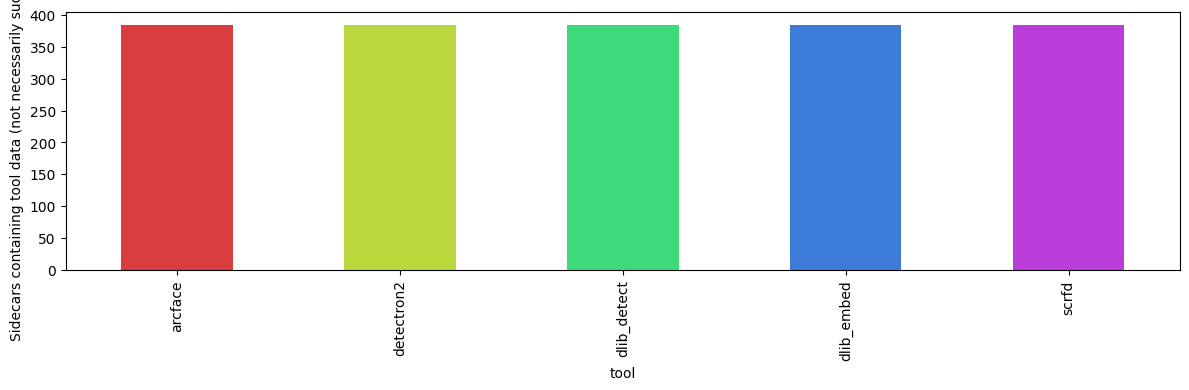

In [3]:
entries = inventory(ROOT, recursive=RECURSIVE)
colors = tool_colors(entries)
inventory_table = pd.DataFrame([
    {"image_index": i, "image": str(e["image"] or "(missing)"),
     "sidecar": str(e["sidecar"]), "status": e["status"],
     "tools": ", ".join(e["sections"]), "records": len(records_for(e))}
    for i, e in enumerate(entries)
])
display(inventory_table)
coverage = pd.DataFrame([
    {"tool": t, "sidecars_with_tool": sum(t in e["sections"] for e in entries),
     "face_records": sum(r["tool"] == t for e in entries for r in records_for(e))}
    for t in colors
])
display(coverage)
if not coverage.empty:
    ax = coverage.plot.bar(x="tool", y="sidecars_with_tool", legend=False,
                           color=[colors[t] for t in coverage.tool], figsize=(12, 4))
    ax.set_ylabel("Sidecars containing tool data (not necessarily successful)")
    plt.tight_layout()
    plt.show()


## 2. Complete image overlay
Every tool keeps its own color throughout the directory. Solid boxes come from a tool's saved geometry. Dashed boxes are reused from SCRFD (or dlib for dlib embeddings/clusters). Shared outlines use different stroke widths so coincident boxes remain visible; filter `TOOLS` to declutter. Tools without geometry still appear in the legend and metadata.

Landmarks are drawn only for known image-coordinate fields. Other outputs (gaze, expression, parsing summaries, etc.) remain in the complete metadata; the notebook does not guess coordinate systems or reconstruct masks absent from the sidecar.


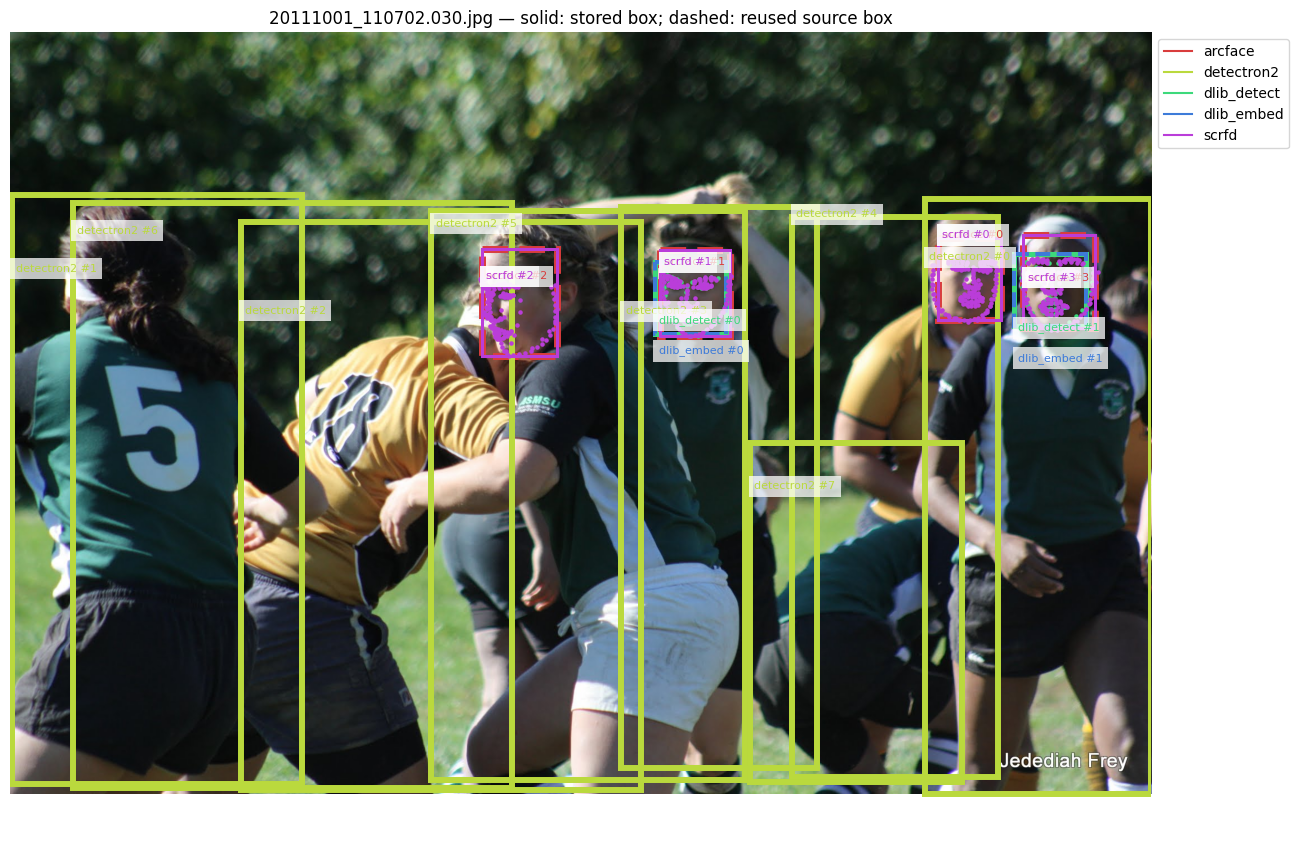

,face_record,tool,tool_record,stored_face_index,bbox,box_source,reused_box
0,0,arcface,0,0,"[1664.908447265625, 368.6537780761719, 1778.28...",scrfd,True
1,1,arcface,1,1,"[1165.85986328125, 390.0199890136719, 1291.129...",scrfd,True
2,2,arcface,2,2,"[845.8759155273438, 387.4861145019531, 980.678...",scrfd,True
3,3,arcface,3,3,"[1817.619384765625, 363.2684631347656, 1946.35...",scrfd,True
4,4,detectron2,0,0,"[1641.005615234375, 298.6285095214844, 2046.22...",detectron2,False
5,5,detectron2,1,1,"[2.2008445262908936, 291.658447265625, 522.519...",detectron2,False
6,6,detectron2,2,2,"[413.30609130859375, 340.3695373535156, 1131.9...",detectron2,False
7,7,detectron2,3,3,"[1096.5823974609375, 313.1761169433594, 1446.7...",detectron2,False
8,8,detectron2,4,4,"[1402.4996337890625, 331.67578125, 1771.314819...",detectron2,False
9,9,detectron2,5,5,"[755.4717407226562, 320.9783020019531, 1318.09...",detectron2,False


In [4]:
IMAGE_INDEX = 0
TOOLS = None  # None = all; or ["scrfd", "dlib_detect", "emotiefflib"]
SHOW_LANDMARKS = True

if not entries:
    raise ValueError("No images or .scar files found. Check ROOT.")
entry = entries[IMAGE_INDEX]
records = records_for(entry)
if entry["image"] is not None:
    fig = draw_review(entry, colors, selected=TOOLS, landmarks=SHOW_LANDMARKS)
    plt.show()
    plt.close(fig)
else:
    print(entry["status"])
show_metadata(entry["raw"], "All sidecar fields — expand for complete values")
display(pd.DataFrame([
    {"face_record": i, "tool": r["tool"], "tool_record": r["index"],
     "stored_face_index": r["face_index"], "bbox": r["bbox"],
     "box_source": r["source"], "reused_box": r["inherited"]}
    for i, r in enumerate(records)
]))


## 3. One face at a time, with overlapping tool results
Choose a `face_record` row above. This shows its crop and every tool record whose box overlaps it at the chosen IoU threshold. Independent detectors are matched spatially, never by equal array position. Indexed analysis results retain their stored SCRFD association; this is not an independently verified match (especially for tools that detect their own faces). Overlap is not identity recognition. No estimated attributes are combined into a “true” answer.


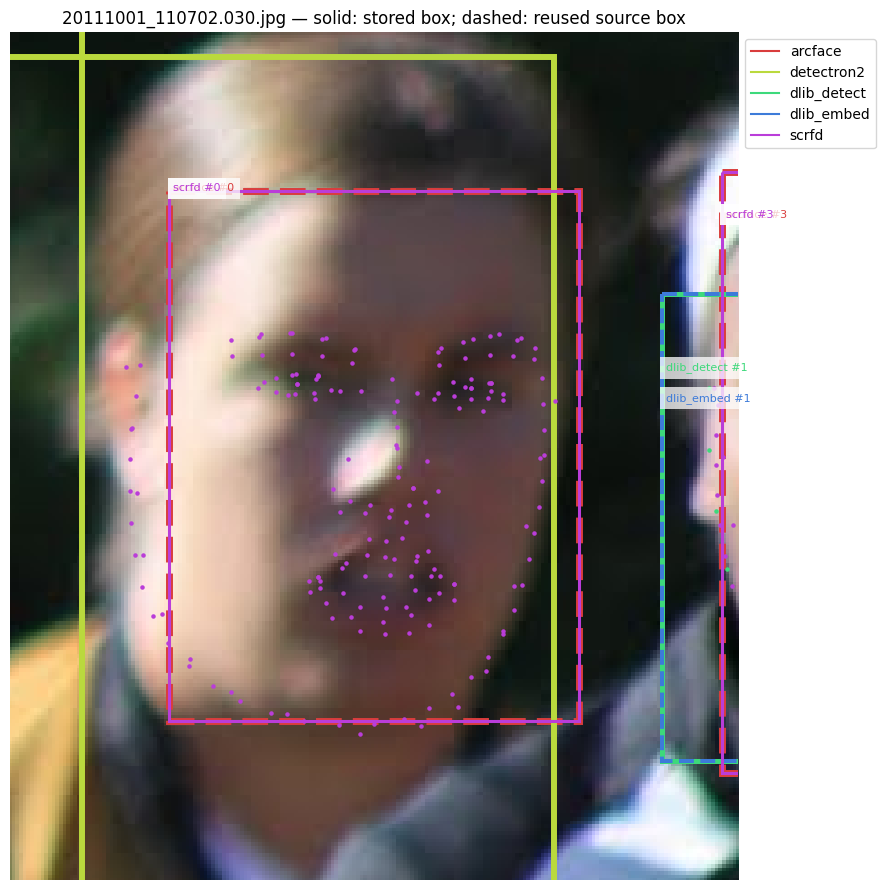

In [5]:
FACE_INDEX = 0

if records:
    focus = records[FACE_INDEX]
    from _tool_review import iou
    related = [r for r in records if r is focus or
               (focus["bbox"] is not None and r["bbox"] is not None
                and iou(focus["bbox"], r["bbox"]) >= IOU_THRESHOLD)]
    if entry["image"] is not None and focus["bbox"] is not None:
        fig = draw_review(entry, colors, selected=TOOLS, focus=focus,
                          landmarks=SHOW_LANDMARKS)
        plt.show()
        plt.close(fig)
    else:
        print("No usable image/box for this record; saved metadata follows.")
    for r in related:
        show_metadata(r, f"{r['tool']} #{r['index']} — complete face result")
else:
    print("No per-face records in this sidecar.")


## 4. Meta analysis: overlapping tools
All cross-tool pairs above the threshold are retained (many-to-many). `reused_box=True` indicates a derived association rather than independent geometric agreement. Coverage above includes tools with no boxes; this table only includes pairs with usable geometry.


In [6]:
overlap_rows = []
for i, item in enumerate(entries):
    overlap_rows.extend(dict(image_index=i, image=str(item["image"]), **row)
                        for row in overlaps(records_for(item), IOU_THRESHOLD))
overlap_table = pd.DataFrame(overlap_rows)
if overlap_table.empty:
    print("No cross-tool overlaps above the threshold.")
else:
    display(overlap_table[overlap_table.image_index == IMAGE_INDEX])
    display(overlap_table.groupby(["tool_a", "tool_b", "reused_box"])
            .agg(overlapping_pairs=("iou", "size"), mean_iou=("iou", "mean"),
                 images=("image_index", "nunique")).reset_index())


,image_index,image,tool_a,record_a,tool_b,record_b,iou,reused_box
0,0,/tun/pictures/2011/10-Oct/20111001_110702.030.jpg,arcface,0,scrfd,0,1.000000,True
1,0,/tun/pictures/2011/10-Oct/20111001_110702.030.jpg,arcface,1,dlib_detect,0,0.741812,True
2,0,/tun/pictures/2011/10-Oct/20111001_110702.030.jpg,arcface,1,dlib_embed,0,0.741812,True
3,0,/tun/pictures/2011/10-Oct/20111001_110702.030.jpg,arcface,1,scrfd,1,1.000000,True
4,0,/tun/pictures/2011/10-Oct/20111001_110702.030.jpg,arcface,2,scrfd,2,1.000000,True
5,0,/tun/pictures/2011/10-Oct/20111001_110702.030.jpg,arcface,3,dlib_detect,1,0.616381,True
6,0,/tun/pictures/2011/10-Oct/20111001_110702.030.jpg,arcface,3,dlib_embed,1,0.616381,True
7,0,/tun/pictures/2011/10-Oct/20111001_110702.030.jpg,arcface,3,scrfd,3,1.000000,True
8,0,/tun/pictures/2011/10-Oct/20111001_110702.030.jpg,dlib_detect,0,dlib_embed,0,1.000000,True
9,0,/tun/pictures/2011/10-Oct/20111001_110702.030.jpg,dlib_detect,0,scrfd,1,0.741812,False


,tool_a,tool_b,reused_box,overlapping_pairs,mean_iou,images
0,arcface,detectron2,True,24,0.417838,20
1,arcface,dlib_detect,True,797,0.657987,252
2,arcface,dlib_embed,True,797,0.657987,252
3,arcface,scrfd,True,1774,0.997839,315
4,detectron2,dlib_detect,False,9,0.403736,9
5,detectron2,dlib_embed,True,9,0.403736,9
6,detectron2,scrfd,False,24,0.417838,20
7,dlib_detect,dlib_embed,True,817,1.000000,259
8,dlib_detect,scrfd,False,797,0.657987,252
9,dlib_embed,scrfd,True,797,0.657987,252


## 5. Optional export
Set `EXPORT_DIR` to save the selected overlay, full sidecar metadata, and directory overlap table. Export goes to a separate directory; inputs are read-only.


In [7]:
EXPORT_DIR = "/tmp"  # e.g. REPO / "review_output"
if EXPORT_DIR is not None:
    import json
    out = Path(EXPORT_DIR).expanduser().resolve()
    if out == ROOT.expanduser().resolve() or out == entry["sidecar"].parent:
        raise ValueError("Choose a separate export directory.")
    out.mkdir(parents=True, exist_ok=True)
    prefix = f"image_{IMAGE_INDEX:05d}"
    if entry["image"] is not None:
        fig = draw_review(entry, colors, selected=TOOLS, landmarks=SHOW_LANDMARKS)
        fig.savefig(out / f"{prefix}_overlay.png", dpi=180, bbox_inches="tight")
        plt.close(fig)
    (out / f"{prefix}_metadata.json").write_text(
        json.dumps(entry["raw"], indent=2, ensure_ascii=False, default=str), encoding="utf-8")
    overlap_table.to_csv(out / "overlapping_tools.csv", index=False)
    inventory_table.to_csv(out / "inventory.csv", index=False)
    print(f"Saved review to {out}")


Saved review to /tmp
